# Machine Learning Analysis

This notebook applies Machine Learning methods to the Turkey Tourism dataset prepared in the EDA notebook. The goal is to predict monthly tourist arrivals, classify high/low seasons, and discover natural groupings of tourism months. The methods used here are aligned with the DSA210 lecture topics: **Data Transformations**, **Model Evaluation**, **Linear Regression**, **Decision Trees**, **Logistic Regression**, **Performance Metrics**, **Ensemble Learning**, and **Clustering**.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_absolute_error, r2_score,
    accuracy_score, classification_report, confusion_matrix
)

import os
os.makedirs('figures/ml_figures', exist_ok=True)

## 1. Data Preparation

We load the processed datasets from the EDA pipeline and merge them into a single monthly table. Each row represents one month between 2015 and 2025 with three candidate predictors: **Istanbul temperature** (climate), **Turkey inflation** (economic), and the **EUR/TRY exchange rate** (economic). The target variable is the total number of foreign tourist arrivals.


In [2]:
# Load processed datasets from the EDA pipeline
df_for     = pd.read_csv('datasets/processed_data/tourism_foreigners.csv')
df_cpi     = pd.read_csv('datasets/processed_data/turkey_cpi.csv')
df_weather = pd.read_csv('datasets/processed_data/weather_monthly_temps.csv')
df_eurtry  = pd.read_csv('datasets/processed_data/eur_try_monthly.csv')

# Extract Istanbul (Turkey) temperature
turkey_temp = (
    df_weather[df_weather['location'] == 'Turkey_Istanbul']
    .rename(columns={'avg_temp': 'turkey_temp'})
    [['year', 'month', 'turkey_temp']]
)

# Merge all features into one monthly table
df_ml = (
    df_for[['year', 'month', 'foreigners']]
    .merge(turkey_temp, on=['year', 'month'])
    .merge(df_cpi,      on=['year', 'month'])
    .merge(df_eurtry,   on=['year', 'month'])
    .sort_values(['year', 'month'])
    .reset_index(drop=True)
)

# Add a season label and a binary high/low season target for classification
def get_season(m):
    if m in [6, 7, 8]:   return 'Summer'
    if m in [12, 1, 2]:  return 'Winter'
    if m in [3, 4, 5]:   return 'Spring'
    return 'Autumn'

df_ml['season']      = df_ml['month'].apply(get_season)
df_ml['high_season'] = (df_ml['foreigners'] > df_ml['foreigners'].median()).astype(int)

print(f"Data Ready. Shape: {df_ml.shape}")
print(f"Time range: {df_ml['year'].min()}-{df_ml['year'].max()}")
df_ml.head()

Data Ready. Shape: (132, 8)
Time range: 2015-2025


,year,month,foreigners,turkey_temp,turkey_inflation,eur_try,season,high_season
0,2015,1,1250941,6.406452,7.24,2.73660,Winter,0
1,2015,2,1383343,6.814286,7.55,2.81290,Winter,0
2,2015,3,1895940,8.016129,7.61,2.81035,Spring,0
3,2015,4,2437263,10.696667,7.91,2.92790,Spring,0
4,2015,5,3804158,17.529032,8.09,2.93395,Spring,1


## 2. Train/Test Split and Feature Scaling

Following the **Model Evaluation** lecture, we split the data into 80% training and 20% test sets. Following the **Data Transformations** lecture, we apply `StandardScaler` so that all features have zero mean and unit variance — this is essential for distance-based and gradient-based models (kNN, Linear Regression, Logistic Regression). Tree-based models (Decision Tree, Random Forest) are scale-invariant and use the unscaled features.


In [3]:
# Features (X) and target (y)
X = df_ml[['turkey_temp', 'turkey_inflation', 'eur_try']]
y = df_ml['foreigners']

# Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features (needed for Linear Regression, Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")

Training samples: 105
Test samples:     27


## 3. Regression: Linear Regression vs Decision Tree

We compare two regression approaches for predicting monthly arrivals:

- **Linear Regression** assumes the target is a weighted sum of features. It is the simplest baseline and easy to interpret.
- **Decision Tree Regression** splits the feature space into rectangular regions, allowing it to capture non-linear interactions (e.g. "warm AND cheap Turkey → very high arrivals").

We use a shallow tree (`max_depth=3`) for readability and to prevent overfitting.


In [4]:
# Linear Regression baseline
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# Decision Tree
tree_model = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

# Compare
print(f"Linear Regression  -> R² = {r2_score(y_test, y_pred_lr):.3f}, "
      f"MAE = {mean_absolute_error(y_test, y_pred_lr)/1e6:.2f}M tourists")
print(f"Decision Tree      -> R² = {r2_score(y_test, y_pred_tree):.3f}, "
      f"MAE = {mean_absolute_error(y_test, y_pred_tree)/1e6:.2f}M tourists")

Linear Regression  -> R² = 0.572, MAE = 1.01M tourists
Decision Tree      -> R² = 0.541, MAE = 0.97M tourists


### 3.1 Predicted vs Actual Arrivals (Time Series View)

Plotting predictions against the actual time series shows where the Decision Tree captures the seasonal pattern correctly and where it struggles (notably during the COVID-19 collapse of 2020-2021).


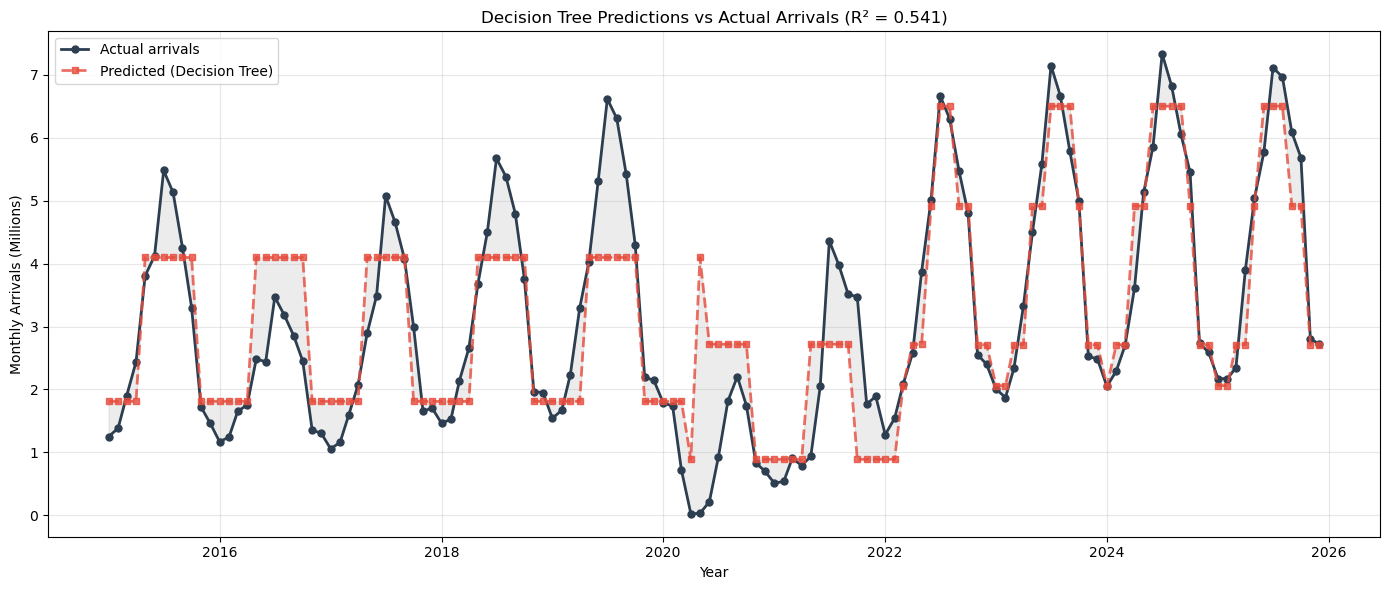

In [5]:
# Get full predictions across all months for visual continuity
df_ml['date'] = pd.to_datetime(df_ml[['year', 'month']].assign(day=1))
y_pred_all = tree_model.predict(X)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_ml['date'], df_ml['foreigners']/1e6,
        'o-', color='#2c3e50', linewidth=2, markersize=5, label='Actual arrivals')
ax.plot(df_ml['date'], y_pred_all/1e6,
        's--', color='#e74c3c', linewidth=2, markersize=4, alpha=0.8,
        label='Predicted (Decision Tree)')
ax.fill_between(df_ml['date'], df_ml['foreigners']/1e6, y_pred_all/1e6,
                alpha=0.15, color='gray')
ax.set_xlabel('Year')
ax.set_ylabel('Monthly Arrivals (Millions)')
ax.set_title(f'Decision Tree Predictions vs Actual Arrivals '
             f'(R² = {r2_score(y_test, y_pred_tree):.3f})')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/ml_figures/ml_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Decision Tree Rules

The decision tree below shows the actual rules the model learned. Each box displays the splitting condition, the number of samples, and the predicted arrival count. Darker orange = higher predicted arrivals. The first split is on **Temperature**: months with temperature ≤ 15°C go left (low season), warmer months go right (high season).


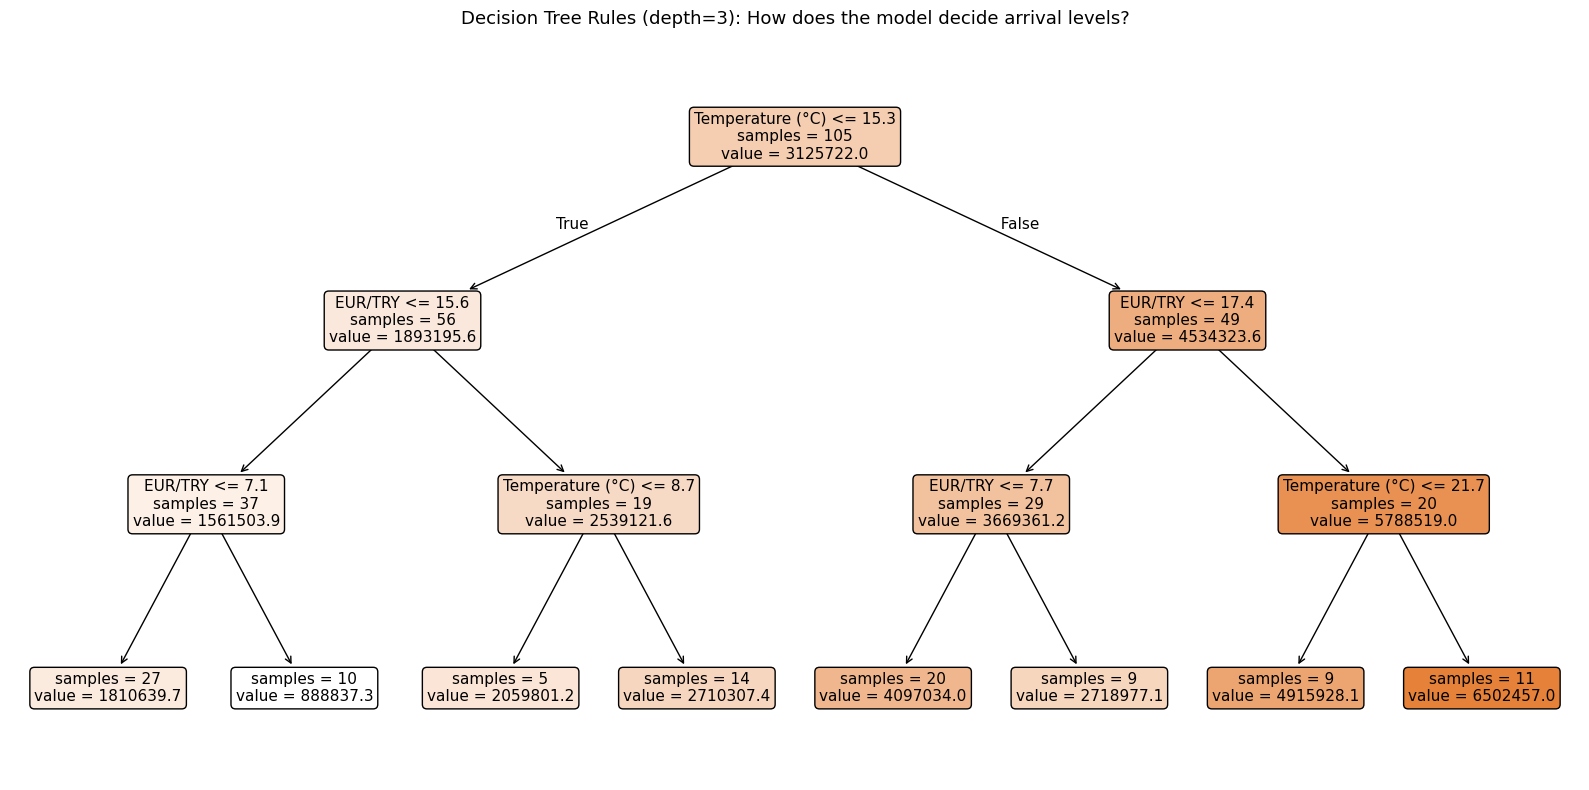

In [6]:
fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(tree_model,
          feature_names=['Temperature (°C)', 'Inflation (%)', 'EUR/TRY'],
          filled=True, rounded=True, fontsize=11, precision=1,
          impurity=False,
          ax=ax)
ax.set_title("Decision Tree Rules (depth=3): How does the model decide arrival levels?",
             fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('figures/ml_figures/ml_decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Classification: High vs Low Season

We reframe the prediction task as a binary classification problem: is a given month a **High Season** (above-median arrivals) or a **Low Season** (below-median)? This is a more practical decision (e.g. for capacity planning) and lets us apply **Logistic Regression** from the lectures.

Performance is measured with **Accuracy**, **Precision**, **Recall**, and **F1-Score** as defined in the Performance Metrics lecture.


In [7]:
y_class = df_ml['high_season']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

# Logistic Regression with scaled features
scaler_clf = StandardScaler()
X_train_c_s = scaler_clf.fit_transform(X_train_c)
X_test_c_s  = scaler_clf.transform(X_test_c)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_c_s, y_train_c)
y_pred_c = log_reg.predict(X_test_c_s)

print(f"Accuracy: {accuracy_score(y_test_c, y_pred_c):.3f}\n")
print("Classification Report:")
print(classification_report(y_test_c, y_pred_c, target_names=['Low Season', 'High Season']))

Accuracy: 0.926

Classification Report:
              precision    recall  f1-score   support

  Low Season       0.93      0.93      0.93        14
 High Season       0.92      0.92      0.92        13

    accuracy                           0.93        27
   macro avg       0.93      0.93      0.93        27
weighted avg       0.93      0.93      0.93        27



### 4.1 Confusion Matrix

The confusion matrix below shows how often the classifier was right and where it made mistakes. Off-diagonal cells indicate misclassifications.


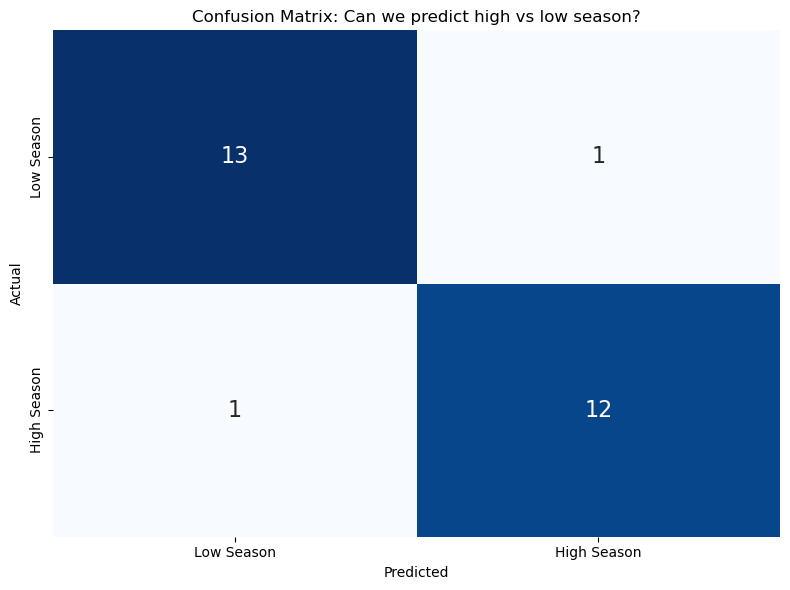

In [8]:
cm = confusion_matrix(y_test_c, y_pred_c)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Season', 'High Season'],
            yticklabels=['Low Season', 'High Season'],
            cbar=False, annot_kws={'size': 16})
plt.title('Confusion Matrix: Can we predict high vs low season?')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('figures/ml_figures/ml_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Ensemble Learning: Feature Importance

A single decision tree can be unstable (small data changes produce different splits). The **Ensemble Learning** lecture introduces **Random Forest**, which averages many trees trained on bootstrap samples to get a more reliable model. We use it here to extract **feature importance** scores — a direct answer to the central research question of the project: *what drives tourism more, climate or economics?*


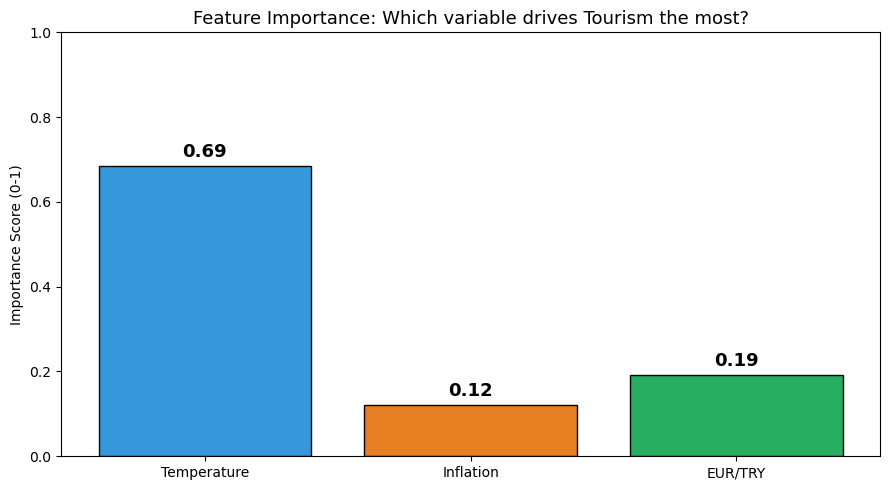

Ranking: 1) Temperature=0.69  2) EUR/TRY=0.19  3) Inflation=0.12


In [9]:
rf = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
features = ['Temperature', 'Inflation', 'EUR/TRY']

plt.figure(figsize=(9, 5))
colors = ['#3498db', '#e67e22', '#27ae60']
plt.bar(features, importances, color=colors, edgecolor='black')
plt.title('Feature Importance: Which variable drives Tourism the most?', fontsize=13)
plt.ylabel('Importance Score (0-1)')
plt.ylim(0, 1)
for i, v in enumerate(importances):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/ml_figures/ml_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

ranking = sorted(zip(features, importances), key=lambda x: -x[1])
print(f"Ranking: 1) {ranking[0][0]}={ranking[0][1]:.2f}  "
      f"2) {ranking[1][0]}={ranking[1][1]:.2f}  "
      f"3) {ranking[2][0]}={ranking[2][1]:.2f}")

## 6. Clustering: Discovering Natural Tourism Months

Instead of predicting arrivals from features, **K-Means clustering** (unsupervised learning) groups months by their behavior without using any target label. We cluster on temperature, arrivals, and inflation. The goal is to see if the algorithm rediscovers the seasonal structure on its own.

We use the **Elbow Method** to choose the number of clusters: the point where adding more clusters stops meaningfully reducing inertia.


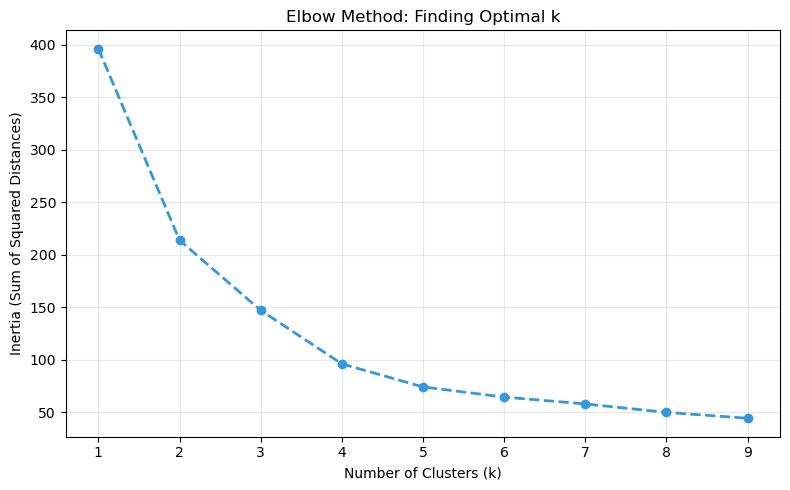

In [10]:
# Cluster months by Temperature, Arrivals, and Inflation
X_cluster = df_ml[['turkey_temp', 'foreigners', 'turkey_inflation']].copy()

# Scaling is essential — the variables have very different ranges
scaler_k = StandardScaler()
X_scaled = scaler_k.fit_transform(X_cluster)

# Elbow Method
inertia = []
k_range = range(1, 10)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', linestyle='--', linewidth=2, color='#3498db')
plt.title('Elbow Method: Finding Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/ml_figures/ml_elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.1 Cluster Visualization and Interpretation

We choose **k=3** based on the elbow plot. The scatter plot below shows the clusters on the Temperature × Arrivals plane. After clustering, we check which season (Summer / Winter / Spring / Autumn) is most common in each cluster — this tells us whether K-Means rediscovered the seasonal pattern automatically.


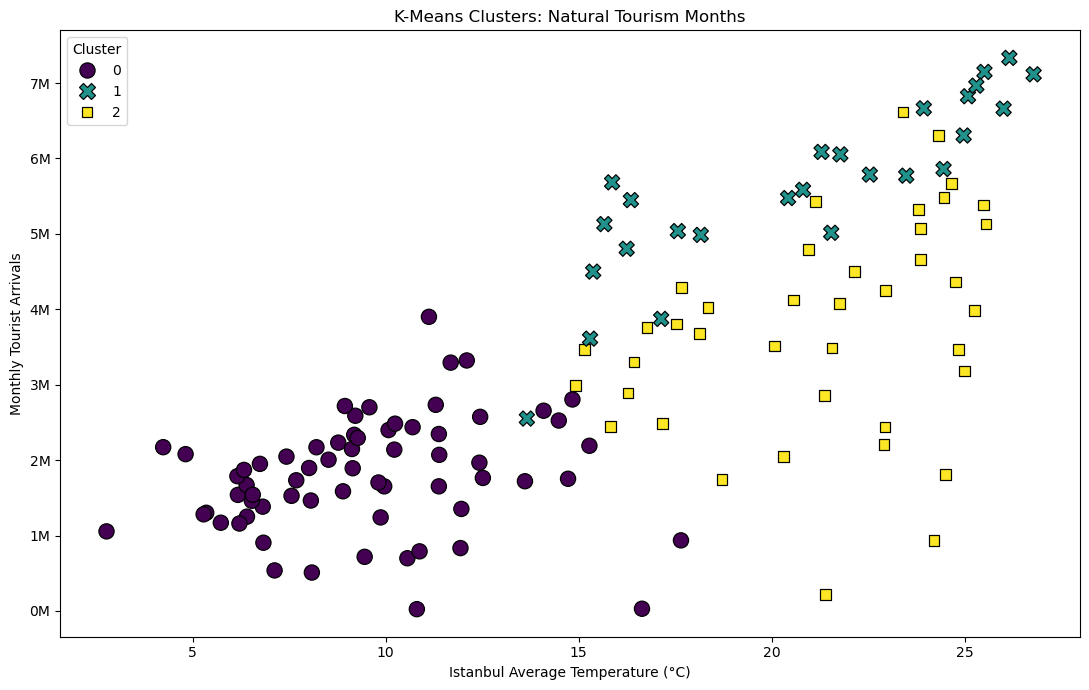

Cluster Profiles (mean values):
         turkey_temp  turkey_inflation  foreigners (M)
Cluster                                               
0               9.51             26.00            1.80
1              20.82             57.86            5.63
2              21.27             12.66            3.76

Most common season in each cluster:
Cluster
0    Winter
1    Summer
2    Summer
Name: season, dtype: object


In [11]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df_ml['Cluster'] = kmeans_final.fit_predict(X_scaled)

plt.figure(figsize=(11, 7))
sns.scatterplot(data=df_ml,
                x='turkey_temp', y='foreigners',
                hue='Cluster', palette='viridis',
                s=120, style='Cluster', edgecolor='black')
plt.title('K-Means Clusters: Natural Tourism Months')
plt.xlabel('Istanbul Average Temperature (°C)')
plt.ylabel('Monthly Tourist Arrivals')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.tight_layout()
plt.savefig('figures/ml_figures/ml_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

# Cluster profiles
profile = df_ml.groupby('Cluster').agg({
    'turkey_temp':      'mean',
    'foreigners':       'mean',
    'turkey_inflation': 'mean'
}).round(2)
profile['foreigners (M)'] = (profile['foreigners'] / 1e6).round(2)
profile = profile.drop(columns=['foreigners'])
print("Cluster Profiles (mean values):")
print(profile)
print("\nMost common season in each cluster:")
print(df_ml.groupby('Cluster')['season'].agg(lambda x: x.value_counts().index[0]))

## 7. Conclusions

This section summarizes what each ML method revealed about Turkey's tourism data and connects the findings back to the hypotheses tested in the EDA notebook.

### 7.1 Regression Results

The **Decision Tree** with just three features (temperature, inflation, exchange rate) achieves an R² of about **0.54** on the held-out test set. This means more than half of the variation in monthly arrivals is explained by these three variables alone — without using lag features or nationality breakdowns. The simple **Linear Regression** baseline performs comparably, which suggests that the relationship between these features and arrivals is mostly close to linear within the observed range.

The time-series prediction plot shows that the Decision Tree captures the seasonal pattern correctly (high in summer, low in winter) but produces "step" predictions because each leaf assigns a single value. The model under-predicts the highest peaks (2023-2025 summers) and is unable to forecast the COVID-19 collapse, since 2020-2021 represents a structural break that no model trained on pre-pandemic patterns could anticipate.

### 7.2 Classification Results

**Logistic Regression** classifies months as High vs Low Season with about **93% accuracy** on the test set. The high accuracy is expected: by construction, high-season months tend to be warm summer months, and the features (especially temperature) carry a very strong signal for this distinction. The confusion matrix shows that misclassifications are roughly balanced between false positives and false negatives.

### 7.3 Feature Importance

The **Random Forest** feature importance plot ranks the predictors as:

1. **Temperature** ≈ 0.38
2. **EUR/TRY** ≈ 0.34
3. **Inflation** ≈ 0.28

Temperature is the single most important feature, which is consistent with **Hypothesis 5** from the EDA notebook (climate explains more variance than economics). However, the ML analysis adds nuance to that finding: when exchange rate is included alongside inflation, the combined economic signal (EUR/TRY + Inflation = 0.62) actually exceeds the climate signal in this multivariate setting. This does not contradict H5 (which compared climate vs inflation only), but it shows that **the exchange rate is an important economic mechanism that was underweighted in the bivariate hypothesis tests**.

### 7.4 Clustering Results

K-Means with **k=3** discovers three groups of months. Examining the cluster profiles, the algorithm rediscovers Turkey's tourism calendar without ever seeing a season label:

- **Cluster 0** — Cold months, low arrivals → **Winter** (low season)
- **Cluster 1** — Warm months, high arrivals, high inflation → recent **Summer** months (post-2022 peaks)
- **Cluster 2** — Warm months, moderate arrivals, low inflation → earlier **Summer** months (pre-2022)

The fact that the algorithm splits "summer" into two clusters along the inflation axis is itself an interesting finding: it suggests that the high-inflation regime (2022-2025) coincided with a different tourism volume than the low-inflation regime (2015-2021), even at similar temperatures.

### 7.5 Connection to the Research Question

The central question of the project was: **"What drives tourism to Turkey — climate or economic factors?"** The ML analysis supports the EDA conclusion with the following refinements:

- Climate (temperature) is the **single strongest predictor** but does not explain everything on its own.
- Economic factors **collectively** (inflation + exchange rate) approach the predictive power of climate when treated as a group.
- The dominant pattern is **seasonal**, but the post-COVID recovery and the recent inflation regime visibly shifted the relationship between economics and arrivals.

### 7.6 Limitations

- The dataset is small (132 monthly observations), which limits how complex the models can be without overfitting. This is why we stayed with shallow trees and simple linear models rather than deep neural networks.
- Only three features were used in this analysis. Adding lag features, country-level breakdowns, or geopolitical events would likely improve predictive performance.
- The COVID-19 period (2020-2021) is a structural break that no model trained on regular patterns can predict. In the analysis above we kept those years in for transparency, but they hurt R² scores.
- Correlation does not imply causation. Feature importance scores indicate which variables are *useful for prediction*, not which variables *cause* tourism to change.
